### problem statement:
   - how some features of the kc-house dataset can be affect the price??

### we will going to use multiple linear regression

In [78]:
import pandas as pd
import seaborn as sns
house_data = pd.read_csv("kc_house_data.csv")
house_data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [79]:
house_data = house_data.drop(columns = "id", axis = 0)
house_data

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [80]:
house_data.shape

(21613, 20)

In [81]:
house_data.dtypes

date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

### house age - add this feature in the DataFrame. 'house age = year built - buying year'

In [82]:
house_data["date_new"] = pd.to_datetime(house_data["date"])

In [83]:
house_data

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_new
0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014-10-13
1,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014-12-09
2,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015-02-25
3,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014-12-09
4,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015-02-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,3,...,1530,0,2009,0,98103,47.6993,-122.346,1530,1509,2014-05-21
21609,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,3,...,2310,0,2014,0,98146,47.5107,-122.362,1830,7200,2015-02-23
21610,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,3,...,1020,0,2009,0,98144,47.5944,-122.299,1020,2007,2014-06-23
21611,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,3,...,1600,0,2004,0,98027,47.5345,-122.069,1410,1287,2015-01-16


In [84]:
house_data["date_new"] = house_data["date_new"].dt.year

In [85]:
house_data

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_new
0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014
1,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014
2,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015
3,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014
4,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,3,...,1530,0,2009,0,98103,47.6993,-122.346,1530,1509,2014
21609,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,3,...,2310,0,2014,0,98146,47.5107,-122.362,1830,7200,2015
21610,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,3,...,1020,0,2009,0,98144,47.5944,-122.299,1020,2007,2014
21611,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,3,...,1600,0,2004,0,98027,47.5345,-122.069,1410,1287,2015


In [86]:
house_data.dtypes

date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
date_new           int32
dtype: object

In [87]:
house_data["house_age"] = house_data["date_new"] - house_data["yr_built"]
house_data

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_new,house_age
0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,59
1,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,63
2,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,82
3,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,49
4,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,3,...,0,2009,0,98103,47.6993,-122.346,1530,1509,2014,5
21609,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,3,...,0,2014,0,98146,47.5107,-122.362,1830,7200,2015,1
21610,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,3,...,0,2009,0,98144,47.5944,-122.299,1020,2007,2014,5
21611,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,3,...,0,2004,0,98027,47.5345,-122.069,1410,1287,2015,11


In [88]:
house_data.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
21608    False
21609    False
21610    False
21611    False
21612    False
Length: 21613, dtype: bool

In [89]:
house_data.drop(columns = ["date","date_new","yr_built"], inplace= True)
house_data

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,house_age
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,0,98178,47.5112,-122.257,1340,5650,59
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1991,98125,47.7210,-122.319,1690,7639,63
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,0,98028,47.7379,-122.233,2720,8062,82
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,0,98136,47.5208,-122.393,1360,5000,49
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,0,98074,47.6168,-122.045,1800,7503,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,0,98103,47.6993,-122.346,1530,1509,5
21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,0,98146,47.5107,-122.362,1830,7200,1
21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,0,98144,47.5944,-122.299,1020,2007,5
21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,0,98027,47.5345,-122.069,1410,1287,11


In [90]:
house_data.shape

(21613, 19)

In [91]:
house_data_imp = house_data[["price","bedrooms","bathrooms","sqft_living","grade","house_age"]]
house_data_imp

,price,bedrooms,bathrooms,sqft_living,grade,house_age
0,221900.0,3,1.00,1180,7,59
1,538000.0,3,2.25,2570,7,63
2,180000.0,2,1.00,770,6,82
3,604000.0,4,3.00,1960,7,49
4,510000.0,3,2.00,1680,8,28
...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,8,5
21609,400000.0,4,2.50,2310,8,1
21610,402101.0,2,0.75,1020,7,5
21611,400000.0,3,2.50,1600,8,11


## linearity check

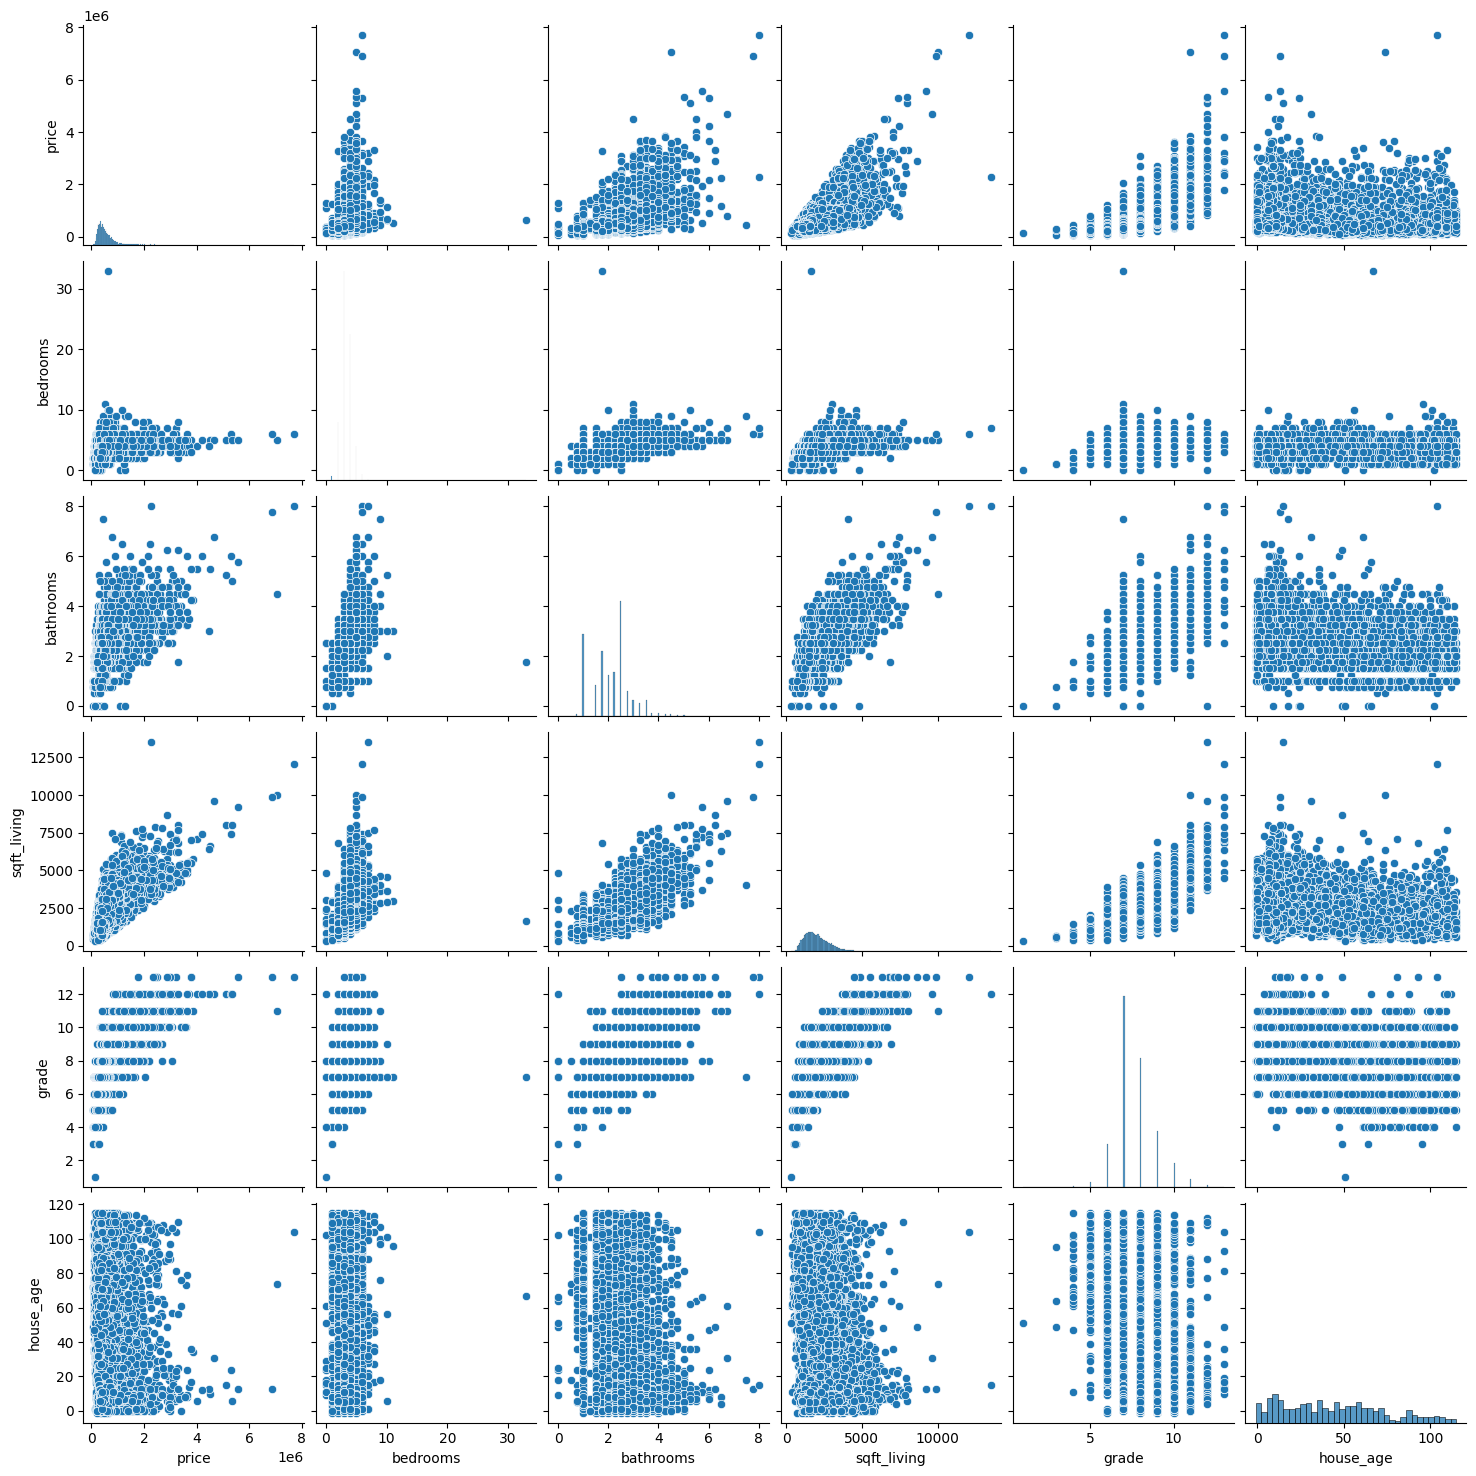

In [92]:
sns.pairplot(house_data_imp)

## no multicollinearity

In [93]:
house_data_imp.corr

<bound method DataFrame.corr of           price  bedrooms  bathrooms  sqft_living  grade  house_age
0      221900.0         3       1.00         1180      7         59
1      538000.0         3       2.25         2570      7         63
2      180000.0         2       1.00          770      6         82
3      604000.0         4       3.00         1960      7         49
4      510000.0         3       2.00         1680      8         28
...         ...       ...        ...          ...    ...        ...
21608  360000.0         3       2.50         1530      8          5
21609  400000.0         4       2.50         2310      8          1
21610  402101.0         2       0.75         1020      7          5
21611  400000.0         3       2.50         1600      8         11
21612  325000.0         2       0.75         1020      7          6

[21613 rows x 6 columns]>

## no auto regression

## model building

In [94]:
X = house_data_imp.drop(columns = "price")
y = house_data_imp["price"]

## model training

In [95]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## model testing

In [96]:
y_pred = linear_model.predict(X)
y_pred

array([303436.12261734, 648890.59549807, 237706.25388095, ...,
        86777.54085925, 406733.13855848,  90858.15795335], shape=(21613,))

## model evaluation

In [97]:
residual = y- y_pred  ##RMSE value
residual

0        -81536.122617
1       -110890.595498
2        -57706.253881
3        126855.088236
4         49200.932287
             ...      
21608     -9443.812055
21609    -47878.062839
21610    315323.459141
21611     -6733.138558
21612    234141.842047
Name: price, Length: 21613, dtype: float64

In [98]:
residual.mean()

np.float64(-1.116914872254347e-10)

In [99]:
linear_model.score(X,y)   ##calculates r2 value ---R2 value

0.6153740723310572

#### another way to find R2 value

In [100]:
from sklearn.metrics import r2_score
r2_val = r2_score(y,y_pred)
r2_val

0.6153740723310572

In [101]:
y_pred = linear_model.predict(X)
y_pred

array([303436.12261734, 648890.59549807, 237706.25388095, ...,
        86777.54085925, 406733.13855848,  90858.15795335], shape=(21613,))

### _after this above y_pred we should do the below step to find both r2 and rmse value_

In [102]:
from sklearn.metrics import mean_squared_error , r2_score
import numpy as np

value_rmse = np.sqrt(mean_squared_error(y,y_pred))
value_r2 = r2_score(y,y_pred)

value_rmse
value_r2

0.6153740723310572

### _if the r2 value is 0.6 or greater than or equal to 0.6 then it's good to maek a model with the data it means "my model can tell the reason for the variation 60% rightly ...the rest of the 40% is the features which i didn't use!!_

## homoscadasticity

In [103]:
import matplotlib.pyplot as plt

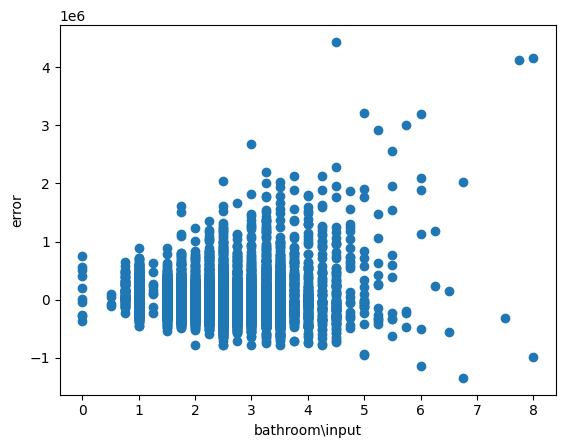

In [118]:
plt.scatter( x = X["bathrooms"], y = residual)
plt.xlabel("bathroom\input")
plt.ylabel("error")
plt.show()

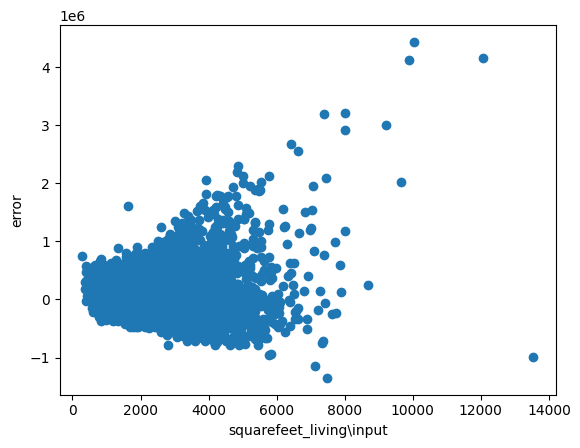

In [117]:
plt.scatter( x = X["sqft_living"], y = residual)
plt.xlabel("squarefeet_living\input")
plt.ylabel("error")
plt.show()

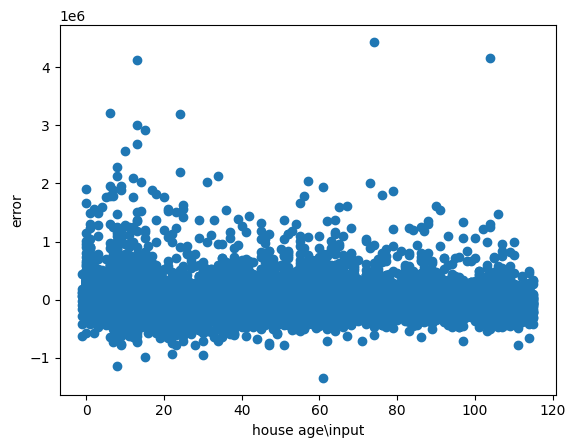

In [116]:
plt.scatter( x = X["house_age"], y = residual)
plt.xlabel("house age\input")
plt.ylabel("error")
plt.show()

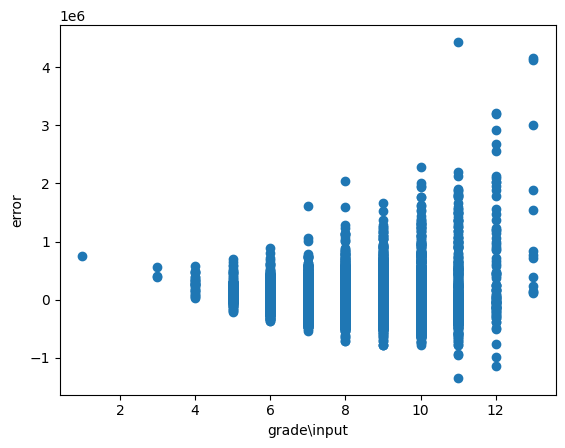

In [114]:
plt.scatter( x = X["grade"], y = residual)
plt.xlabel("grade\input")
plt.ylabel("error")
plt.show()

## zero residual mean

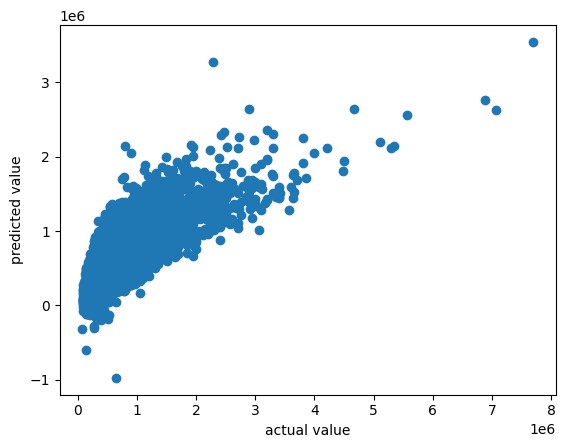

In [112]:
plt.scatter(x= y, y= y_pred)
plt.xlabel("actual value")
plt.ylabel("predicted value")
plt.show()

## model deployment

In [121]:
from pickle import dump
dump(linear_model,open("KC_house_predict_intelligence.pkl", "wb"))

In [122]:
from pickle import load
loaded_data = load(open("KC_house_predict_intelligence.pkl","rb"))

In [123]:
loaded_data.predict(X)

array([303436.12261734, 648890.59549807, 237706.25388095, ...,
        86777.54085925, 406733.13855848,  90858.15795335], shape=(21613,))